# Basal melt parameterisation analysis
[Finucane and Stewart (2024)](https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2024GL108196) present a parameterisation for basal melt of ice shelves based on bathymetric and hydrographic data. Let's see how much those estimates change with the different bathymetry products.

This notebook pretty much just implements the code presented in Garret's [repo](https://github.com/garrettdreyfus/geostrophic_basal_melt?tab=readme-ov-file).

In [1]:
import xarray as xr
import datetime

from scipy.ndimage import label 
import numpy as np
from tqdm import tqdm
import gsw,xarray, pyproj
import matplotlib.pyplot as plt
import numpy as np
import pickle
import matplotlib.colors as colors
import glob
from pathlib import Path


In [2]:
import dask.distributed as dask

client = dask.Client(threads_per_worker = 1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 7
Total threads: 7,Total memory: 32.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42231,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:35921,Total threads: 1
Dashboard: /proxy/46697/status,Memory: 4.57 GiB
Nanny: tcp://127.0.0.1:36641,


2026-04-10 14:20:45,313 - distributed.nanny.memory - WARNING - Worker tcp://127.0.0.1:38771 (pid=3817688) exceeded 95% memory budget. Restarting...
2026-04-10 14:20:45,479 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:38771' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('rechunk-merge-0365d7ad48001c598eb37505d938fcc1', 0, 0, 0, 0), ('rechunk-merge-0365d7ad48001c598eb37505d938fcc1', 0, 0, 1, 1), ('getitem-7cb2fa198d618959d18fcfd5cb9147d6', 0, 0), ('array-97122163ab77509659e8919d5295dd36', 0), ('array-726593c77f68f65ae0669dea9fece5f2', 0), ('rechunk-merge-0365d7ad48001c598eb37505d938fcc1', 0, 0, 1, 0), ('rechunk-merge-0365d7ad48001c598eb37505d938fcc1', 0, 0, 0, 1), ('getitem-8d25d43948633bbe0585e2eade350539', 0, 0), 'finalize-hlgfinalizecompute-8ed4b8466e1b426896e2bcbdba3706c6'} (stimulus_id='handle-worker-cleanup-1775794845.4792197')
2026-04-10 14:20:45,505 - distributed.nanny - WARNING - Restarting worker
2026-04-10 14

In [3]:
import os
os.chdir('/home/552/ed7737/coding-and-projects/panant_bathy_ensemble/'+
                'antarctic-bathymetry-project/geostrophic_basal_melt')

In [4]:
# import all the bits of code from basal melt repo
import bathtub as bt
import HUB
import woa
import paperfigures as pf
import cdw

In [5]:
#These flags just make it easy to turn off and steps of the analysis 
writeBedMach = True
writeShelfNumbers = True
writeHUB = True
writePolygons = True
writeGL = True
createWOA = True
createGISS = True
createClosestShelfPoints = True
createQuants = True
createSlopes = True

In [6]:
##################################################
#Create Polygon objects from MEASURES files
##################################################

if writePolygons:
    bt.save_polygons();

with open("data/shelfpolygons.pickle","rb") as f:
    shelf_polygons = pickle.load(f);

In [7]:
# shelf_polygons.keys()


In [8]:
def open_topog_file(short_name, data_dir = '/g/data/jk72/ed7737/access-om3/inputs/4km-PanAntarctic/bathy_products/'):
    """Quick and dirty function for opening the MOM6 topog files."""
    
    topog = xr.open_dataset(data_dir + short_name + '/topog.nc', chunks='auto')
    
    return topog

def write_topog_file(topog, short_name, data_dir = '/g/data/jk72/ed7737/access-om3/inputs/4km-PanAntarctic/bathy_products/'):
    """Quick and dirty function for opening the MOM6 topog files."""
    
    topog.to_netcdf(data_dir + short_name + '/topog_with_HUB.nc')
    
    return

def generateHUBs(depth,ice,resolution=5):
    #We don't care about the structure of the bathymetry off the shelf break for now
    # so we'll call the off shelf water the part that's greater than 2000 meters deep
    # and just set it to 2000 meters
    depth[depth<-2000] = -2000

    
    ## Grab a single point in the open ocean. We just made all the open ocean one depth so it is connected 
    openoceancoord = np.where(depth==-2000)
    openoceancoord = (openoceancoord[0][-1],openoceancoord[1][-1])

    ## Create the slices we'd like to search from -2000 to 0 using `resolution` provided in function call
    slices = - np.asarray(range(0,2000,resolution)[::-1])
    ## A matrix output we will fill with nans as we go.
    HUB = np.full_like(depth,np.nan)
    for iso_z in tqdm(slices):
        ### A mask that shows all points below our search depth that arent land or grounded ice.
        below = np.logical_and((depth<=iso_z),ice!=1)
        ### Use the image library label function to label connected regions.
        regions, _ = label(below)
        ### If any region is connected to open ocean at this depth and it hasn't been assigned a GLIB before (all ocean points are connected at z=0)
        ### then set it's glib to iso_z -20. The minus 20 is there because we are looking for the depth at which its not connected
        HUB[np.logical_and(regions==regions[openoceancoord],np.isnan(HUB))] = iso_z-resolution
    return HUB

In [9]:
topog_names = ['GEBCO24', 'GEBCO25', 'MEAN', 'DTU_DKL',
               'DTU_DNN', 'NCU_DNN', 'NRL_CNN', 'SRTM15_V2_7']

data_dir = '/g/data/jk72/ed7737/access-om3/inputs/4km-PanAntarctic/bathy_products/'


In [9]:

for name in topog_names:
    topog = open_topog_file(name)

    # Original code had icemask==0 in the ice regions, which hurt my brain, so I flipped it.
    icemask = xr.where(topog.depth>=10, 0, 1)
    icemask = icemask.where(topog.geolat_t<=-60, 0)
    icemask = icemask.values

    bedvalues = -topog.depth.values

    print("Calculating Hub for {0}".format(name))
    topog_hub = generateHUBs(bedvalues,icemask)
    
    topog['HUB'] = (('ny', 'nx'), topog_hub)

    today = datetime.datetime.today().strftime("%Y-%m-%d %H:%M")
    topog.attrs['history'] +='\n added highest unconnected isobath {0}'.format(today)
    
    topog.to_netcdf(data_dir + name + '/topog_with_HUB.nc')
    


Calculating Hub for GEBCO24


100%|██████████| 400/400 [00:18<00:00, 21.66it/s]


Calculating Hub for GEBCO25


100%|██████████| 400/400 [00:18<00:00, 21.71it/s]


Calculating Hub for MEAN


...

100%|██████████| 400/400 [00:18<00:00, 21.97it/s]


Calculating Hub for NRL_CNN


100%|██████████| 400/400 [00:18<00:00, 21.73it/s]


Calculating Hub for SRTM15_V2_7


100%|██████████| 400/400 [00:18<00:00, 21.47it/s]


In [10]:
files = sorted(glob.glob('/g/data/jk72/ed7737/access-om3/inputs/'+
                                    '4km-PanAntarctic/bathy_products/*/topog_with_HUB.nc'))

# get a coordinate for the new dimension
bathy_product=[]
for file in files:
    path_with_file = Path(file)
    bathy_product.append(path_with_file.parent.name)
    
topogs_with_hub = xr.open_mfdataset(files, chunks='auto',
                                    combine='nested', concat_dim='bathy_product',
                                   )

topogs_with_hub['bathy_product'] = sorted(bathy_product)

In [11]:



topogs_with_hub

<xarray.Dataset> Size: 997MB
Dimensions:            (bathy_product: 8, ny: 1442, nx: 4320)
Coordinates:
  * bathy_product      (bathy_product) <U11 352B 'DTU_DKL' ... 'SRTM15_V2_7'
Dimensions without coordinates: ny, nx
Data variables:
    depth              (bathy_product, ny, nx) float32 199MB dask.array<chunksize=(1, 1442, 4320), meta=np.ndarray>
    sea_area_fraction  (bathy_product, ny, nx) float32 199MB dask.array<chunksize=(1, 1442, 4320), meta=np.ndarray>
    geolon_t           (bathy_product, ny, nx) float32 199MB dask.array<chunksize=(1, 1442, 4320), meta=np.ndarray>
    geolat_t           (bathy_product, ny, nx) float32 199MB dask.array<chunksize=(1, 1442, 4320), meta=np.ndarray>
    HUB                (bathy_product, ny, nx) float32 199MB dask.array<chunksize=(1, 1442, 4320), meta=np.ndarray>
Attributes:
    original_file:  topog_new_fillfraction_edited_deseas.nc
    input_file:     /g/data/vk83/prerelease/configurations/inputs/access-om3/...
    history:        Fri Jan 16 15:08:27 2026 +1100: topogtools min_max_depth ...

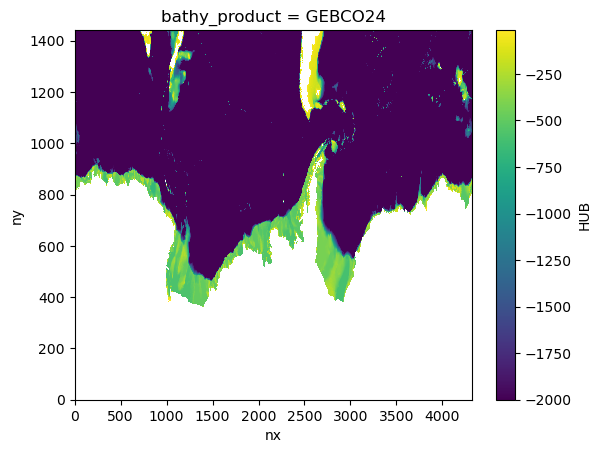

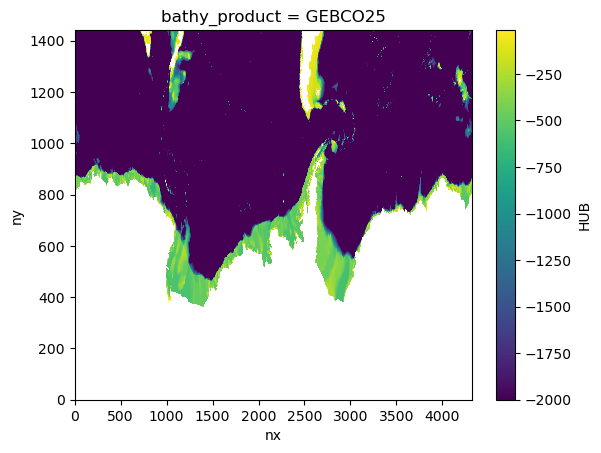

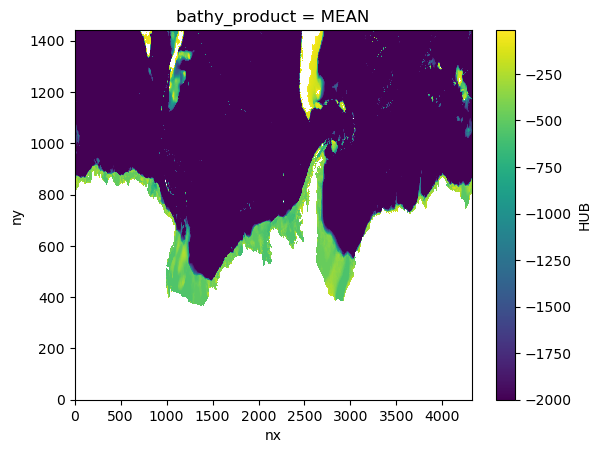

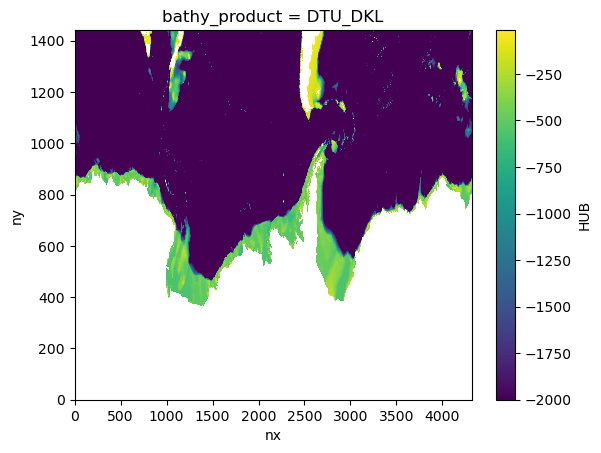

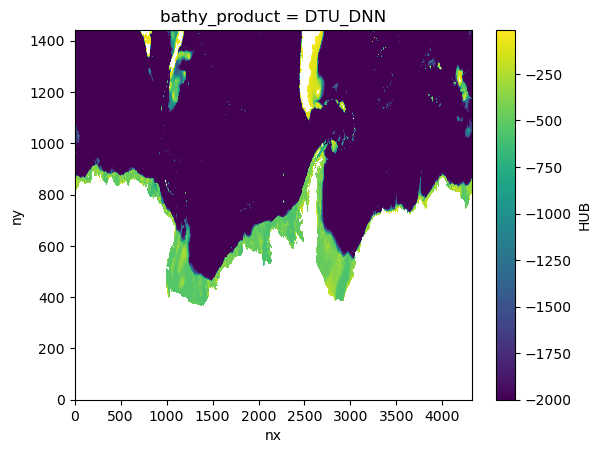

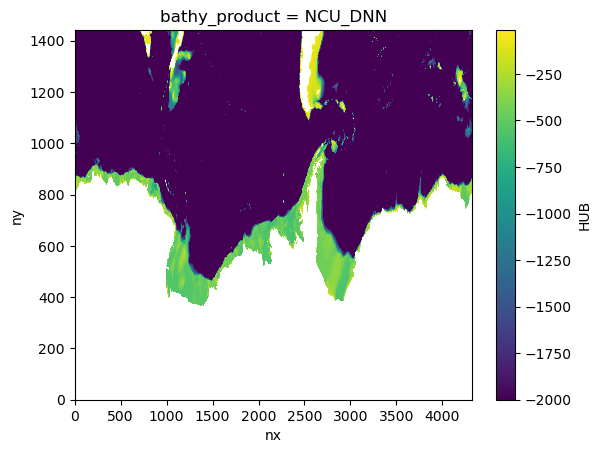

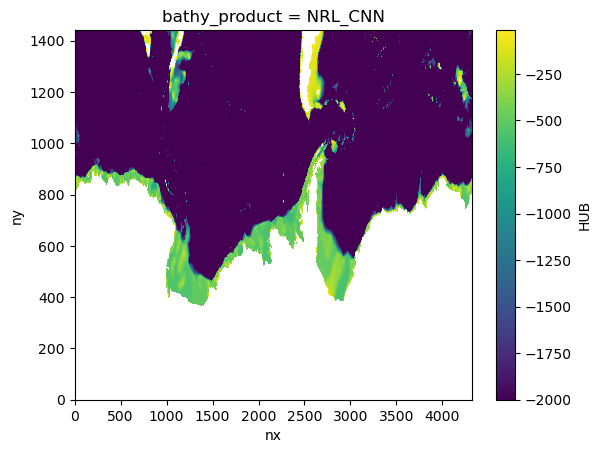

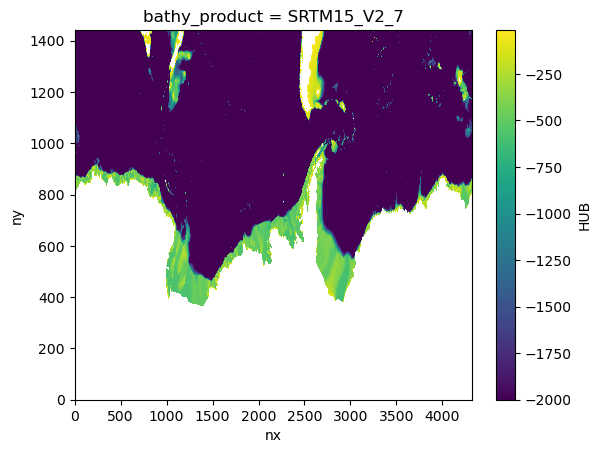

In [13]:
for name in topog_names:
    plt.figure()
    topogs_with_hub['HUB'].sel(bathy_product=name).plot()
    plt.savefig('/home/552/ed7737/coding-and-projects/panant_bathy_ensemble/'+
            'antarctic-bathymetry-project/analysis/HUB-plots/{0}_HUB.png'.format(name),
            dpi=200, bbox_inches='tight')

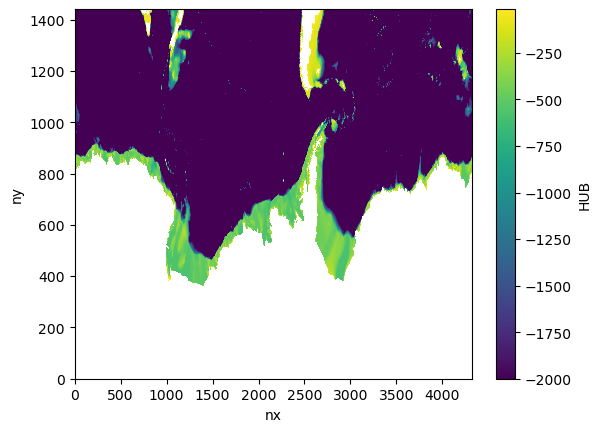

In [14]:
topogs_with_hub['HUB'].mean(dim='bathy_product').plot()

In [15]:
ML_topogs_HUB_std = topogs_with_hub['HUB'].sel(bathy_product=['DTU_DKL','DTU_DNN',
            'NCU_DNN', 'NRL_CNN']).std(dim='bathy_product')

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.02/lib/python3.11/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


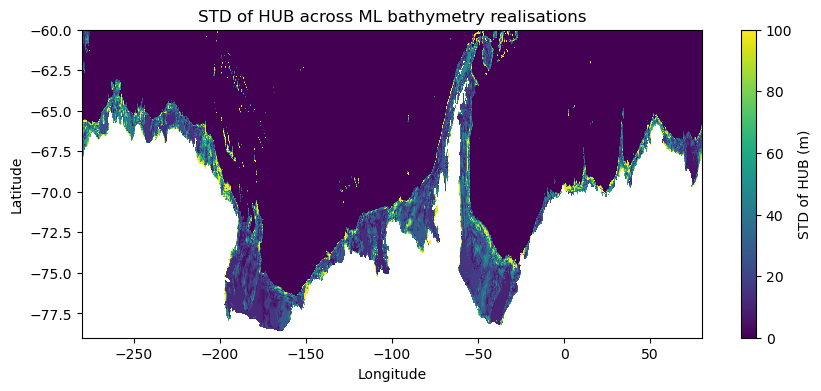

In [16]:
plt.figure(figsize=(10,4))
plt.pcolormesh(topogs_with_hub.sel(bathy_product='MEAN')['geolon_t'],
               topogs_with_hub.sel(bathy_product='MEAN')['geolat_t'],
               ML_topogs_HUB_std, vmin=0, vmax=100)

plt.ylim(-79, -60)
plt.xlabel('Longitude')
plt.ylabel('Latitude')

CB = plt.colorbar()
CB.set_label('STD of HUB (m)')
plt.title('STD of HUB across ML bathymetry realisations')
plt.savefig('/home/552/ed7737/coding-and-projects/panant_bathy_ensemble/'+
            'antarctic-bathymetry-project/analysis/ML_bathymetries_std_HUB.png',
            dpi=200, bbox_inches='tight')

In [17]:


all_topogs_HUB_std = topogs_with_hub['HUB'].sel(bathy_product=['GEBCO24', 'GEBCO25',
                'DTU_DKL', 'DTU_DNN', 'NCU_DNN', 'NRL_CNN',
                'SRTM15_V2_7']).std(dim='bathy_product')

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.02/lib/python3.11/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


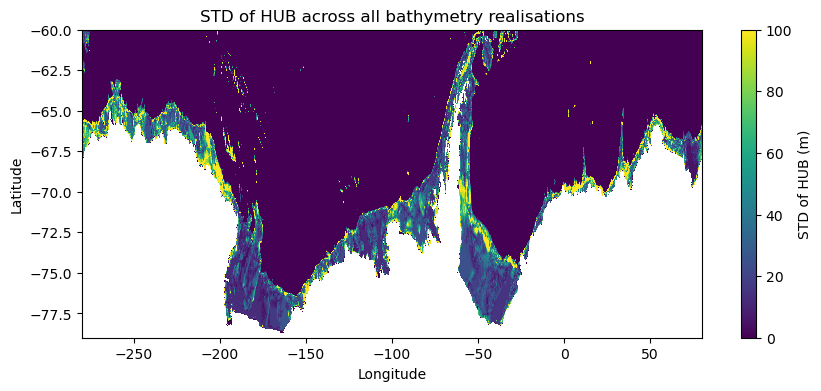

In [18]:
plt.figure(figsize=(10,4))
plt.pcolormesh(topogs_with_hub.sel(bathy_product='MEAN')['geolon_t'],
               topogs_with_hub.sel(bathy_product='MEAN')['geolat_t'],
               all_topogs_HUB_std, vmin=0, vmax=100)

plt.ylim(-79, -60)
plt.xlabel('Longitude')
plt.ylabel('Latitude')

CB = plt.colorbar()
CB.set_label('STD of HUB (m)')
plt.title('STD of HUB across all bathymetry realisations')
plt.savefig('/home/552/ed7737/coding-and-projects/panant_bathy_ensemble/'+
            'antarctic-bathymetry-project/analysis/all_bathymetries_std_HUB.png',
            dpi=200, bbox_inches='tight')

# build a nearest ice shelf mask

In [12]:
import geopandas as gpd
import xarray as xr
import numpy as np
import pandas as pd

Shapefile columns: ['NAME', 'Regions', 'Subregions', 'TYPE', 'Asso_Shelf', 'geometry']
Shapefile CRS: EPSG:3031
Shelf bounds (m, EPSG:3031): [-2508074.68072635 -2143924.79330131  2745433.40095524  2241490.25787429]


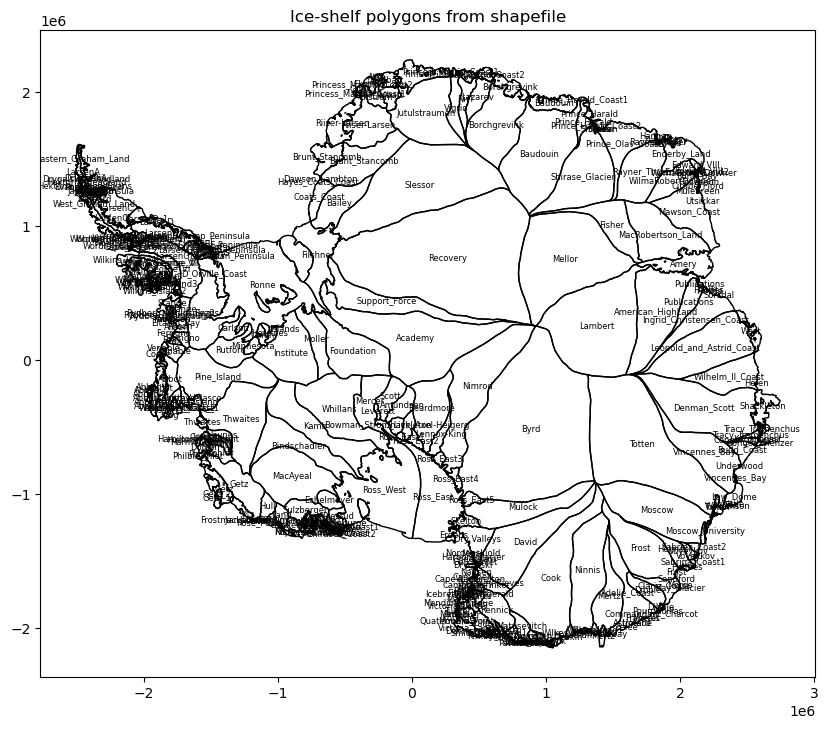

In [13]:
# Load ice-shelf boundaries shapefile
shp_path = "../geostrophic_basal_melt/regions/IceBoundaries_Antarctica_v02.shp"
shelf = gpd.read_file(shp_path)
print("Shapefile columns:", shelf.columns.tolist())
print("Shapefile CRS:", shelf.crs)
print("Shelf bounds (m, EPSG:3031):", shelf.total_bounds)

# Quick plot of the shelf polygons (for sanity check)
label_size = 6  # adjust this to make labels smaller/larger
ax = shelf.plot(figsize=(10, 10), edgecolor="black", facecolor="none")
ax.set_title("Ice-shelf polygons from shapefile")

# Add labels (using polygon centroids)
# NOTE: This can be crowded; adjust label_size as needed.
shelf_centroids = shelf.copy()
shelf_centroids["centroid"] = shelf_centroids.geometry.centroid

# Pick the shelf-name column
shelf_name_col = "NAME"
for _, row in shelf_centroids.iterrows():
    if pd.notna(row[shelf_name_col]):
        ax.text(
            row["centroid"].x,
            row["centroid"].y,
            str(row[shelf_name_col]),
            fontsize=label_size,
            ha="center",
            va="center",
            clip_on=True,
        )

In [14]:
def create_shelf_name_number_dict(shelf_gdf, shelf_name_col="NAME"):
    """Build 2-way dictionaries between shelf names and integer IDs."""
    unique_shelves = sorted(pd.Series(shelf_gdf[shelf_name_col]).dropna().unique())
    shelf_to_num = {name: i for i, name in enumerate(unique_shelves)}
    num_to_shelf = {i: name for name, i in shelf_to_num.items()}
    return shelf_to_num, num_to_shelf

In [15]:
def print_summary_stats(product, shelf_da, pts_proj, max_distance_km, nearest, shelf_name_col):

    print("Using bathy_product:", product)
    print("Finished building array:", shelf_da.shape)
    
    # Summary stats for assigned points
    print(f"Total points (depth mask): {len(pts_proj)}")
    print(f"Points assigned to a shelf (within {max_distance_km} km):", nearest[shelf_name_col].notna().sum())
    print(f"Unassigned points (beyond {max_distance_km} km):", nearest[shelf_name_col].isna().sum())
    print(f"Unique shelves assigned: {len(nearest[shelf_name_col].dropna().unique())}")

    print("Distances (m) stats (assigned points):", nearest.loc[nearest[shelf_name_col].notna(), "dist_m"].describe())
    
#    vals, counts = np.unique(shelf_da.values[assigned_mask], return_counts=True)
#    sorted_ix = np.argsort(counts)[::-1]
#    print("Top 10 assigned shelves (code: count -> name):")
#    for i in sorted_ix[:10]:
#        code = int(vals[i])
#        print(f"  {code}: {counts[i]} -> {num_to_shelf.get(code, '<unknown>')}")
    
    print('\n')
    print('Metadata for the data array')
    print(shelf_da.attrs)
    
def map_depth_mask_points_to_closest_shelf(
    bathymetry_product_name,
    min_mask_depth,
    max_mask_depth,
    shelf_to_num,
    ds=None,
    shelf_gdf=None,
    shelf_name_col="NAME",
    max_distance_km=500):
    """Return an xarray DataArray of closest shelf IDs for points in the depth mask."""

    available_products = set(ds["bathy_product"].values.tolist())
    if bathymetry_product_name not in available_products:
        raise ValueError(
            f"Unknown bathymetry_product_name={bathymetry_product_name!r}. "
            f"Choose from: {sorted(available_products)}"
        )

    ds_sel = ds.sel(bathy_product=bathymetry_product_name)
    depth = ds_sel["depth"]
    depth_mask = (depth >= min_mask_depth) & (depth <= max_mask_depth)

    lon = ds_sel["geolon_t"].values
    lat = ds_sel["geolat_t"].values
    lon_flat = lon.ravel()
    lat_flat = lat.ravel()
    mask_flat = depth_mask.values.ravel()
    keep = np.isfinite(lon_flat) & np.isfinite(lat_flat) & mask_flat

    pts = gpd.GeoDataFrame(
        {"lon": lon_flat[keep], "lat": lat_flat[keep]},
        geometry=gpd.points_from_xy(lon_flat[keep], lat_flat[keep]),
        crs="EPSG:4326",
    )
    pts_proj = pts.to_crs(shelf_gdf.crs)

    shelf_dissolved = shelf_gdf.dissolve(by=shelf_name_col).reset_index()
    nearest = gpd.sjoin_nearest(
        pts_proj,
        shelf_dissolved[[shelf_name_col, "geometry"]],
        how="left",
        distance_col="dist_m",
        max_distance=max_distance_km * 1000,
    )

    if nearest.index.duplicated().any():
        nearest = nearest[~nearest.index.duplicated(keep="first")]

    keep_idx = np.flatnonzero(keep)
    if len(nearest) != len(keep_idx):
        raise ValueError(
            f"Mismatch between kept points ({len(keep_idx)}) and nearest rows ({len(nearest)})."
        )

    shelf_array = np.full(lon_flat.shape, np.nan, dtype=float)
    numeric_values = np.array(
        [shelf_to_num.get(name, np.nan) for name in nearest[shelf_name_col].values],
        dtype=float,
    )
    shelf_array[keep_idx] = numeric_values
    shelf_array = shelf_array.reshape(lon.shape)

    shelf_da = xr.DataArray(
        shelf_array,
        dims=["ny", "nx"],
        coords={"geolat_t": ds_sel["geolat_t"], "geolon_t": ds_sel["geolon_t"]},
        name="closest_shelf_id",
    )
    shelf_da.attrs["bathymetry_product"] = str(bathymetry_product_name)
    shelf_da.attrs["min_mask_depth"] = float(min_mask_depth)
    shelf_da.attrs["max_mask_depth"] = float(max_mask_depth)
    shelf_da.attrs["max_distance_km"] = float(max_distance_km)

    print_summary_stats(product, shelf_da, pts_proj, max_distance_km, nearest, shelf_name_col)
    
    return shelf_da

In [16]:
topogs_with_hub["bathy_product"].values


array(['DTU_DKL', 'DTU_DNN', 'GEBCO24', 'GEBCO25', 'MEAN', 'NCU_DNN',
       'NRL_CNN', 'SRTM15_V2_7'], dtype='<U11')

In [71]:
# Give it a whirl with one of the datasets
product = 'NRL_CNN'

shelf_to_num, num_to_shelf = create_shelf_name_number_dict(shelf, shelf_name_col=shelf_name_col)

shelf_da = map_depth_mask_points_to_closest_shelf(
    bathymetry_product_name=product,
    min_mask_depth=100,
    max_mask_depth=2500,
    shelf_to_num=shelf_to_num,
    ds=topogs_with_hub,
    shelf_gdf=shelf,
    shelf_name_col=shelf_name_col,
    max_distance_km=400)



Using bathy_product: NRL_CNN
Finished building array: (1442, 4320)
Total points (depth mask): 593569
Points assigned to a shelf (within 400 km): 409268
Unassigned points (beyond 400 km): 184301
Unique shelves assigned: 228
Distances (km) stats (assigned points): count    409.268000
mean     121.166439
std       96.513765
min        0.000000
25%       42.192064
50%       97.316031
75%      179.298393
max      399.998142
Name: dist_m, dtype: float64
Top 10 assigned shelves (code: count -> name):
  121: 58402 -> Islands
  230: 30532 -> Ross_West
  222: 25042 -> Ronne
  275: 20546 -> Victoria_Land2
  138: 15243 -> LarsenD
  285: 14461 -> West_Graham_Land
  44: 14025 -> Coats_Coast
  224: 13670 -> Ross_East
  30: 11963 -> Brunt_Stancomb
  0: 11088 -> Abbot


Metadata for the data array
{'bathymetry_product': 'NRL_CNN', 'min_mask_depth': 100.0, 'max_mask_depth': 2500.0, 'max_distance_km': 400.0}


## Plots as a sanity check

In [25]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs


Text(0.5, 1.0, 'Shelf assignments and ice-shelf polygons')

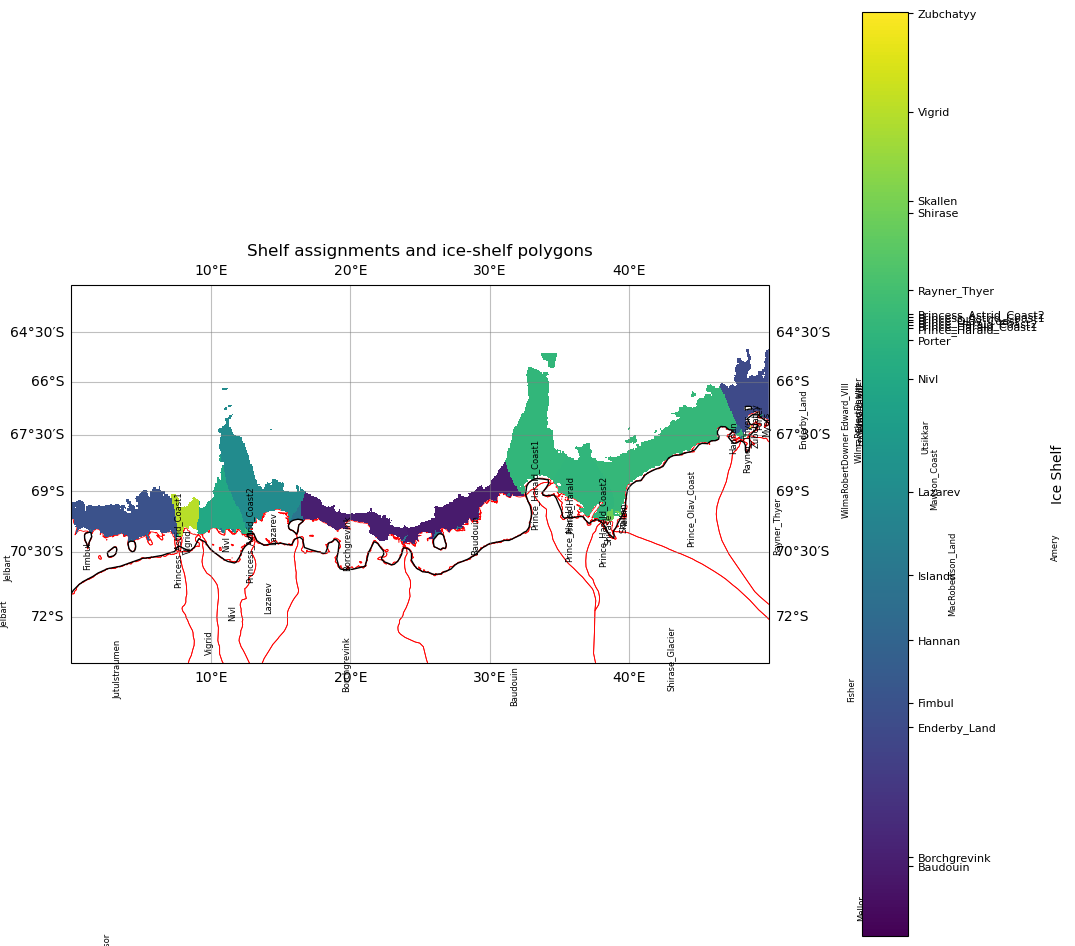

In [41]:
# --- Summary plot (0-50E, 63-70S) ---
region_lon = (0, 50)
region_lat = (-73, -63)

proj = ccrs.Mercator()  # or PlateCarree() if you prefer lat/lon

# Get the actual lon/lat values for comparison (handle 2D coordinates)
lon_2d = shelf_da['geolon_t'].values
lat_2d = shelf_da['geolat_t'].values

# Create mask for the region of interest
region_mask = ((lon_2d >= region_lon[0]) & 
               (lon_2d <= region_lon[1]) &
               (lat_2d >= region_lat[0]) & 
               (lat_2d <= region_lat[1]))

# Find which shelf codes actually exist in the full shelf_da where the region mask is True
region_shelf_codes = sorted([int(code) for code in np.unique(shelf_da.values[region_mask]) 
                             if np.isfinite(code)])

region_shelf_names = [num_to_shelf[code] for code in region_shelf_codes]

fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(1, 1, 1, projection=proj)

# Set extent in PlateCarree lon/lat
ax.set_extent([region_lon[0], region_lon[1], region_lat[0], region_lat[1]], crs=ccrs.PlateCarree())

# background
ax.coastlines(resolution='50m', color='black', linewidth=1)
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, color='gray', alpha=0.5)

# Plot shelf polygons (in PlateCarree)
shelf.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=0.6,
        transform=ccrs.SouthPolarStereo(true_scale_latitude=-71))

# Add labels (using polygon centroids)
# NOTE: This can be crowded; adjust label_size as needed.
label_size = 6  # adjust this to make labels smaller/larger
shelf_centroids = shelf.copy()
shelf_centroids["centroid"] = shelf_centroids.geometry.centroid

# Pick the shelf-name column
shelf_name_col = "NAME"
for _, row in shelf_centroids.iterrows():
    if pd.notna(row[shelf_name_col]):
        ax.text(
            row["centroid"].x,
            row["centroid"].y,
            str(row[shelf_name_col]),
            fontsize=label_size,
            rotation='vertical',
            ha="center",
            va="center",
            clip_on=True,
            transform=ccrs.SouthPolarStereo(true_scale_latitude=-71)
        )


# Plot shelf assignments with pcolormesh
im = ax.pcolormesh(shelf_da['geolon_t'],
                    shelf_da['geolat_t'],
                    shelf_da,
                   vmin=0, vmax=len(num_to_shelf),
                   transform=ccrs.PlateCarree())

# Create colorbar with only the ice shelf names in the region
cbar = plt.colorbar(im, ax=ax, pad=0.1, shrink=1.0, orientation='vertical')
cbar.set_label('Ice Shelf', fontsize=10)

# Set colorbar ticks to match shelf codes present in region
if region_shelf_codes:
    cbar.set_ticks([code + 0.5 for code in region_shelf_codes])
    cbar.set_ticklabels(region_shelf_names, fontsize=8)

ax.set_title('Shelf assignments and ice-shelf polygons')


Text(0.5, 1.0, 'Shelf assignments and ice-shelf polygons')

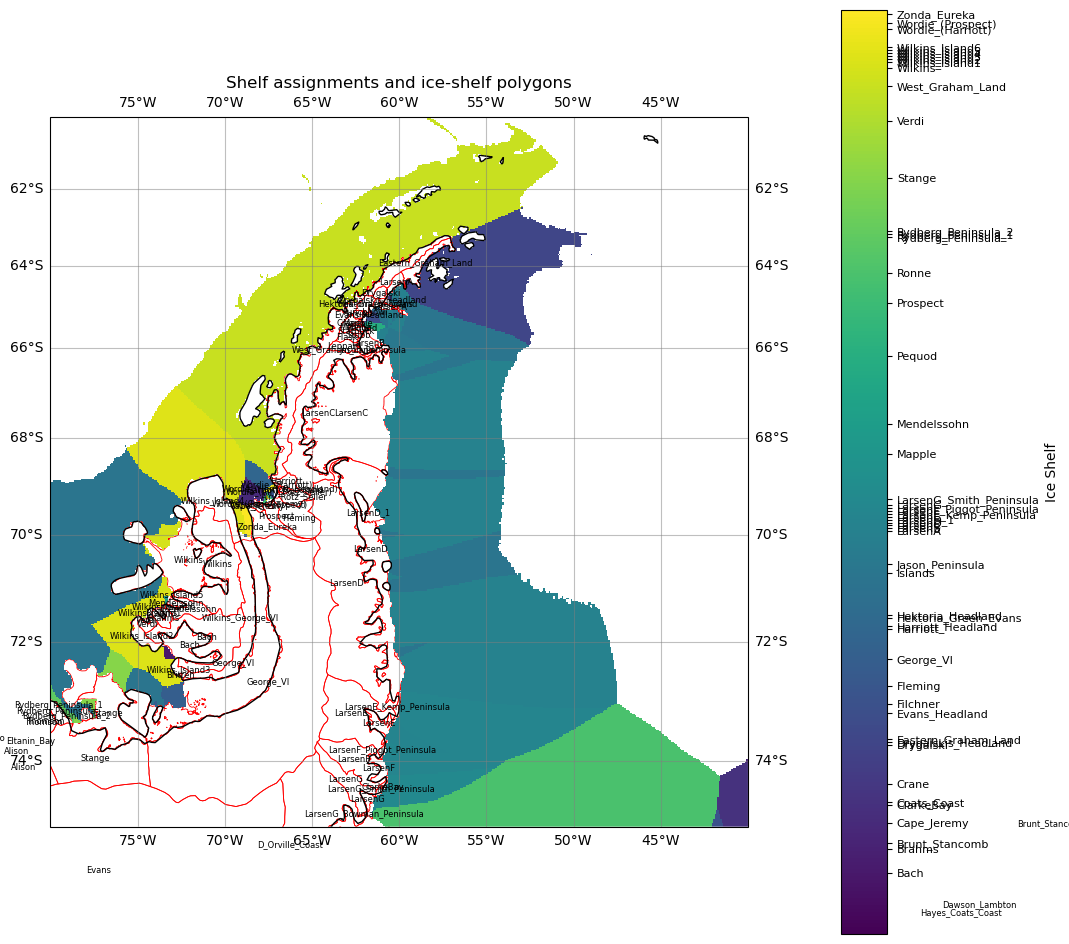

In [42]:
# --- Summary plot (80-40W, 75-60S) ---
# Note: longitude is wrapped from -280 to 80, so -80 to -40 is directly usable
region_lon = (-80, -40)
region_lat = (-75, -60)

proj = ccrs.Mercator()  # or PlateCarree() if you prefer lat/lon

# Get the actual lon/lat values for comparison (handle 2D coordinates)
lon_2d = shelf_da['geolon_t'].values
lat_2d = shelf_da['geolat_t'].values

# Create mask for the region of interest
region_mask = ((lon_2d >= region_lon[0]) & 
               (lon_2d <= region_lon[1]) &
               (lat_2d >= region_lat[0]) & 
               (lat_2d <= region_lat[1]))

# Find which shelf codes actually exist in the full shelf_da where the region mask is True
region_shelf_codes = sorted([int(code) for code in np.unique(shelf_da.values[region_mask]) 
                             if np.isfinite(code)])
region_shelf_names = [num_to_shelf[code] for code in region_shelf_codes]

fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(1, 1, 1, projection=proj)

# Set extent in PlateCarree lon/lat
ax.set_extent([region_lon[0], region_lon[1], region_lat[0], region_lat[1]], crs=ccrs.PlateCarree())

# background
ax.coastlines(resolution='50m', color='black', linewidth=1)
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, color='gray', alpha=0.5)

# Plot shelf polygons
shelf.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=0.6,
        transform=ccrs.SouthPolarStereo(true_scale_latitude=-71))

# Add labels (using polygon centroids)
# NOTE: This can be crowded; adjust label_size as needed.
label_size = 6  # adjust this to make labels smaller/larger
shelf_centroids = shelf.copy()
shelf_centroids["centroid"] = shelf_centroids.geometry.centroid

# Pick the shelf-name column
shelf_name_col = "NAME"
for _, row in shelf_centroids.iterrows():
    if pd.notna(row[shelf_name_col]):
        ax.text(
            row["centroid"].x,
            row["centroid"].y,
            str(row[shelf_name_col]),
            fontsize=label_size,
            ha="center",
            va="center",
            clip_on=True,
            transform=ccrs.SouthPolarStereo(true_scale_latitude=-71)
        )

# Plot shelf assignments with pcolormesh
im = ax.pcolormesh(shelf_da['geolon_t'],
                    shelf_da['geolat_t'],
                    shelf_da,
                   vmin=0, vmax=len(num_to_shelf),
                   transform=ccrs.PlateCarree())

# Create colorbar with only the ice shelf names in the region
cbar = plt.colorbar(im, ax=ax, pad=0.1, shrink=1.0, orientation='vertical')
cbar.set_label('Ice Shelf', fontsize=10)

# Set colorbar ticks to match shelf codes present in region
if region_shelf_codes:
    cbar.set_ticks([code + 0.5 for code in region_shelf_codes])
    cbar.set_ticklabels(region_shelf_names, fontsize=8)

ax.set_title('Shelf assignments and ice-shelf polygons')





# Average HUB just in front of each iceshelf

In [17]:
# Find all points within XX km of the ice shelf front
product = 'NRL_CNN'

shelf_to_num, num_to_shelf = create_shelf_name_number_dict(shelf, shelf_name_col=shelf_name_col)

grounding_zone_da = map_depth_mask_points_to_closest_shelf(
    bathymetry_product_name=product,
    min_mask_depth=1,
    max_mask_depth=6000,
    shelf_to_num=shelf_to_num,
    ds=topogs_with_hub,
    shelf_gdf=shelf,
    shelf_name_col=shelf_name_col,
    max_distance_km=10)



Using bathy_product: NRL_CNN
Finished building array: (1442, 4320)
Total points (depth mask): 3321481
Points assigned to a shelf (within 10 km): 27998
Unassigned points (beyond 10 km): 3293483
Unique shelves assigned: 232
Distances (m) stats (assigned points): count    27998.000000
mean      4894.218401
std       2973.995736
min          0.000000
25%       2386.222772
50%       4927.293470
75%       7450.881260
max       9999.226020
Name: dist_m, dtype: float64


Metadata for the data array
{'bathymetry_product': 'NRL_CNN', 'min_mask_depth': 1.0, 'max_mask_depth': 6000.0, 'max_distance_km': 10.0}


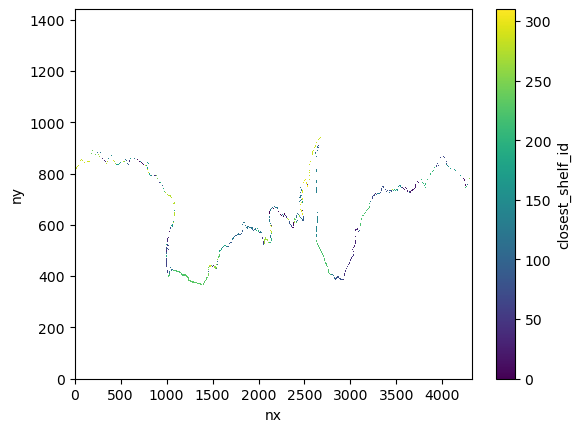

In [18]:
grounding_zone_da.plot()

Text(0.5, 1.0, 'HUB and for Baudouin')

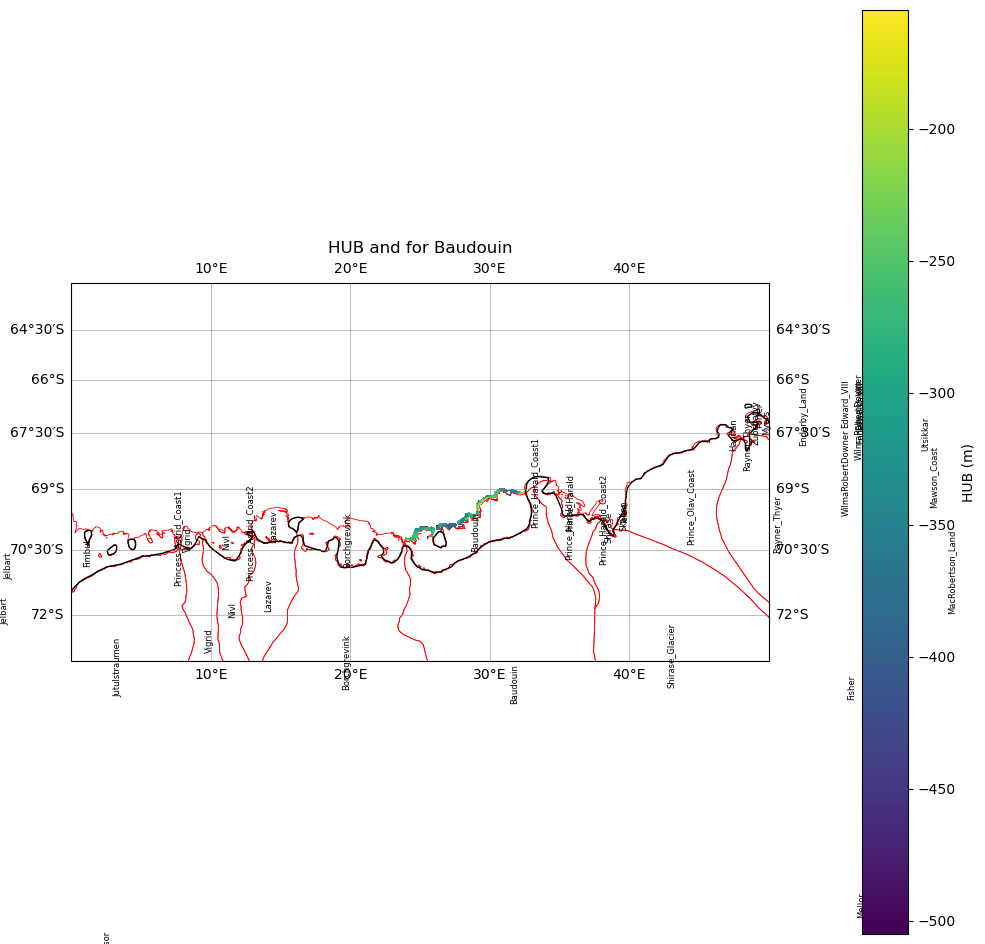

In [90]:
# --- Summary plot (0-50E, 63-70S) ---
region_lon = (0, 50)
region_lat = (-73, -63)

shelf_name = 'Baudouin'

proj = ccrs.Mercator()  # or PlateCarree() if you prefer lat/lon

# Get the actual lon/lat values for comparison (handle 2D coordinates)
lon_2d = shelf_da['geolon_t'].values
lat_2d = shelf_da['geolat_t'].values

# Create mask for the region of interest
region_mask = ((lon_2d >= region_lon[0]) & 
               (lon_2d <= region_lon[1]) &
               (lat_2d >= region_lat[0]) & 
               (lat_2d <= region_lat[1]))

# Find which shelf codes actually exist in the full shelf_da where the region mask is True
region_shelf_codes = sorted([int(code) for code in np.unique(shelf_da.values[region_mask]) 
                             if np.isfinite(code)])
region_shelf_names = [num_to_shelf[code] for code in region_shelf_codes]

fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(1, 1, 1, projection=proj)

# Set extent in PlateCarree lon/lat
ax.set_extent([region_lon[0], region_lon[1], region_lat[0], region_lat[1]], crs=ccrs.PlateCarree())

# background
ax.coastlines(resolution='50m', color='black', linewidth=1)
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, color='gray', alpha=0.5)

# Plot shelf polygons (in PlateCarree)
shelf.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=0.6,
        transform=ccrs.SouthPolarStereo(true_scale_latitude=-71))

# Add labels (using polygon centroids)
# NOTE: This can be crowded; adjust label_size as needed.
label_size = 6  # adjust this to make labels smaller/larger
shelf_centroids = shelf.copy()
shelf_centroids["centroid"] = shelf_centroids.geometry.centroid

# Pick the shelf-name column
shelf_name_col = "NAME"
for _, row in shelf_centroids.iterrows():
    if pd.notna(row[shelf_name_col]):
        ax.text(
            row["centroid"].x,
            row["centroid"].y,
            str(row[shelf_name_col]),
            fontsize=label_size,
            rotation='vertical',
            ha="center",
            va="center",
            clip_on=True,
            transform=ccrs.SouthPolarStereo(true_scale_latitude=-71)
        )


# Plot shelf assignments with pcolormesh
im = ax.pcolormesh(topogs_with_hub['geolon_t'].sel(bathy_product='DTU_DKL'),
                    topogs_with_hub['geolat_t'].sel(bathy_product='DTU_DKL'),
                    topogs_with_hub['HUB'].sel(bathy_product='DTU_DKL').where(grounding_zone_da==shelf_to_num[shelf_name]),
                   transform=ccrs.PlateCarree())

# Create colorbar
cbar = plt.colorbar(im, ax=ax, pad=0.1, shrink=1.0, orientation='vertical')
cbar.set_label('HUB (m)', fontsize=10)


ax.set_title('HUB and for {0}'.format(shelf_name))


In [36]:
def plot_hub_for_shelf(n, savefig=False):
    hub_values = []
    hub_std = []
    for name in topog_names:
        hub_values.append(topogs_with_hub['HUB'].sel(bathy_product=name).where(grounding_zone_da==n).mean().load())
        hub_std.append(topogs_with_hub['HUB'].sel(bathy_product=name).where(grounding_zone_da==n).std().load())
        
    plt.errorbar(np.arange(8), hub_values, hub_std, capsize=3,
                 marker='o', linewidth=1, elinewidth=2)
    plt.xticks(np.arange(8), topog_names, rotation='vertical')
    plt.title(num_to_shelf[n])
    plt.ylim(-1200,0)

    if savefig:
        plt.savefig('/home/552/ed7737/coding-and-projects/panant_bathy_ensemble/antarctic-bathymetry-project/analysis/HUB-plots/HUB_by_shelf/{0}.png'.format(n),
                    dpi=150, bbox_inches='tight')
    return hub_values, hub_std

264


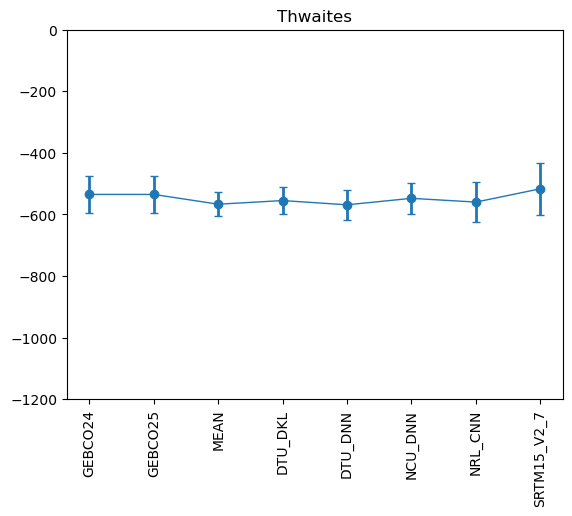

In [49]:
n = shelf_to_num['Thwaites']
print(n)
_ = plot_hub_for_shelf(n, savefig=False)


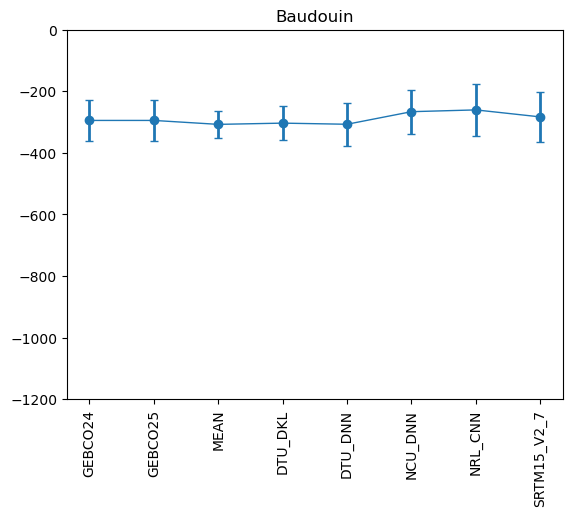

In [52]:
n = shelf_to_num['Baudouin']
_ = plot_hub_for_shelf(n)

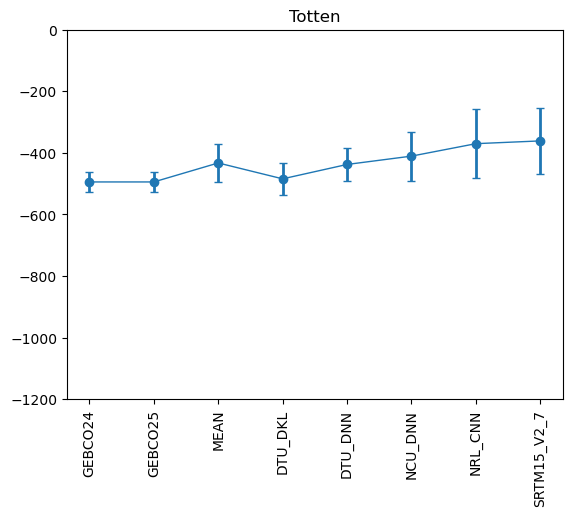

In [53]:
n = shelf_to_num['Totten']
_ = plot_hub_for_shelf(n)

In [42]:
hub_values = np.full((311,8), np.nan)
hub_std = np.full((311,8), np.nan)

# hub_values = xr.DataArray(hub_values, 


for i in range(311):
    hub_values[i,:], hub_std[i,:] = plot_hub_for_shelf(i, savefig=True)
    plt.close()

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


# Load ocean data and calculate H_CDW
This is needed for the F&S (2024) melt parameterisation.

Select ocean cells between 1500 and 2500 m in depth.

In [54]:
ds_woa_temp = xr.open_dataset('/g/data/jk72/ed7737/datasets/world-ocean-atlas/woa18_decav_t00_04.nc', chunks='auto', decode_times=False)
ds_woa_salt = xr.open_dataset('/g/data/jk72/ed7737/datasets/world-ocean-atlas/woa18_decav_s00_04.nc', chunks='auto', decode_times=False)

In [67]:
ds_woa_temp

<xarray.Dataset> Size: 4GB
Dimensions:             (lat: 720, nbounds: 2, lon: 1440, depth: 102, time: 1)
Coordinates:
  * lat                 (lat) float32 3kB -89.88 -89.62 -89.38 ... 89.62 89.88
  * lon                 (lon) float32 6kB -179.9 -179.6 -179.4 ... 179.6 179.9
  * depth               (depth) float32 408B 0.0 5.0 10.0 ... 5.4e+03 5.5e+03
  * time                (time) float32 4B 4.326e+03
Dimensions without coordinates: nbounds
Data variables:
    crs                 int32 4B ...
    lat_bnds            (lat, nbounds) float32 6kB dask.array<chunksize=(720, 2), meta=np.ndarray>
    lon_bnds            (lon, nbounds) float32 12kB dask.array<chunksize=(1440, 2), meta=np.ndarray>
    depth_bnds          (depth, nbounds) float32 816B dask.array<chunksize=(102, 2), meta=np.ndarray>
    climatology_bounds  (time, nbounds) float32 8B dask.array<chunksize=(1, 2), meta=np.ndarray>
    t_an                (time, depth, lat, lon) float32 423MB dask.array<chunksize=(1, 52, 360, 720), meta=np.ndarray>
    t_mn                (time, depth, lat, lon) float32 423MB dask.array<chunksize=(1, 52, 360, 720), meta=np.ndarray>
    t_dd                (time, depth, lat, lon) float64 846MB dask.array<chunksize=(1, 52, 360, 720), meta=np.ndarray>
    t_sd                (time, depth, lat, lon) float32 423MB dask.array<chunksize=(1, 52, 360, 720), meta=np.ndarray>
    t_se                (time, depth, lat, lon) float32 423MB dask.array<chunksize=(1, 52, 360, 720), meta=np.ndarray>
    t_oa                (time, depth, lat, lon) float32 423MB dask.array<chunksize=(1, 52, 360, 720), meta=np.ndarray>
    t_gp                (time, depth, lat, lon) float64 846MB dask.array<chunksize=(1, 52, 360, 720), meta=np.ndarray>
Attributes: (12/49)
    Conventions:                     CF-1.6, ACDD-1.3
    title:                           World Ocean Atlas 2018 : sea_water_tempe...
    summary:                         Climatological mean temperature for the ...
    references:                      Locarnini, R. A., A. V. Mishonov, O. K. ...
    institution:                     National Centers for Environmental Infor...
    comment:                         global climatology as part of the World ...
    ...                              ...
    publisher_email:                 NCEI.info@noaa.gov
    nodc_template_version:           NODC_NetCDF_Grid_Template_v2.0
    license:                         These data are openly available to the p...
    metadata_link:                   https://www.nodc.noaa.gov/OC5/woa18/
    date_created:                    2019-07-29 
    date_modified:                   2019-07-29

In [69]:
foo = grounding_zone_da.assign_coords(geolon_t=(((grounding_zone_da.geolon_t + 180) % 360) - 180))

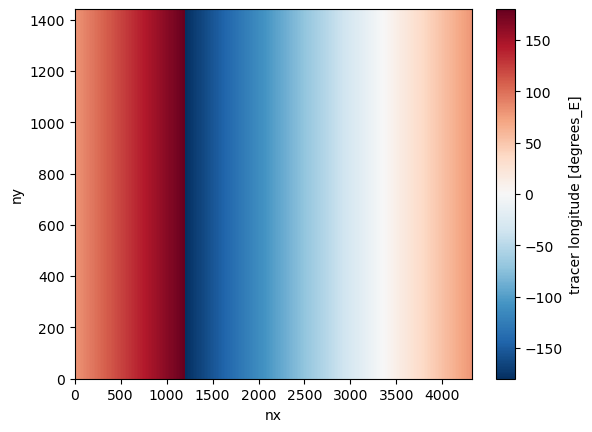

In [71]:
foo.geolon_t.plot()

In [66]:
print(grounding_zone_da['geolon_t'].min().values)
print(grounding_zone_da['geolon_t'].max().values)

-279.95834
79.958336


In [72]:
ds_woa_salt_regridded = ds_woa_salt['s_an'].interp({'lat':foo['geolat_t'], 'lon':foo['geolon_t']}, method='linear')
ds_woa_temp_regridded = ds_woa_temp['t_an'].interp({'lat':foo['geolat_t'], 'lon':foo['geolon_t']}, method='linear')


## Plot as sanity check
We've got an issue with the longitude. The model longitude fields are from -280 to 80, which makes the interpolation awkward. Need to fix that.

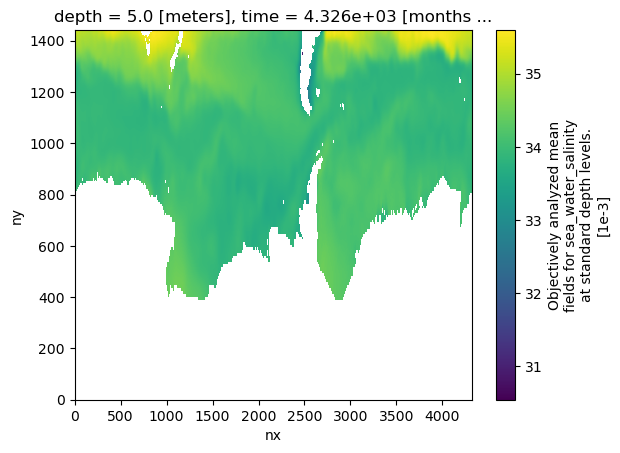

In [73]:
ds_woa_salt_regridded.sel(depth=5.0).plot()


## mask by depth and match to ice shelves

In [88]:
# Find all points in depth range 1500 - 2500 m and assign to shelf
product = 'NRL_CNN'
# product = topogs_with_hub["bathy_product"].values[0]

shelf_to_num, num_to_shelf = create_shelf_name_number_dict(shelf, shelf_name_col=shelf_name_col)

hydrography_mask_da = map_depth_mask_points_to_closest_shelf(
    bathymetry_product_name=product,
    min_mask_depth=1500,
    max_mask_depth=2500,
    shelf_to_num=shelf_to_num,
    ds=topogs_with_hub,
    shelf_gdf=shelf,
    shelf_name_col=shelf_name_col,
    max_distance_km=500)


Using bathy_product: NRL_CNN
Finished building array: (1442, 4320)
Total points (depth mask): 155632
Points assigned to a shelf (within 500 km): 71489
Unassigned points (beyond 500 km): 84143
Unique shelves assigned: 74
Distances (m) stats (assigned points): count     71489.000000
mean     205776.182121
std      120240.352791
min           0.000000
25%      108429.889462
50%      183305.882039
75%      293419.311220
max      499998.592852
Name: dist_m, dtype: float64


Metadata for the data array
{'bathymetry_product': 'NRL_CNN', 'min_mask_depth': 1500.0, 'max_mask_depth': 2500.0, 'max_distance_km': 500.0}


## Select a particular ice shelf

In [97]:
# shelf_id = shelf_to_num['Baudouin']
# print(shelf_id)

shelf_id = 56

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 29.72 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


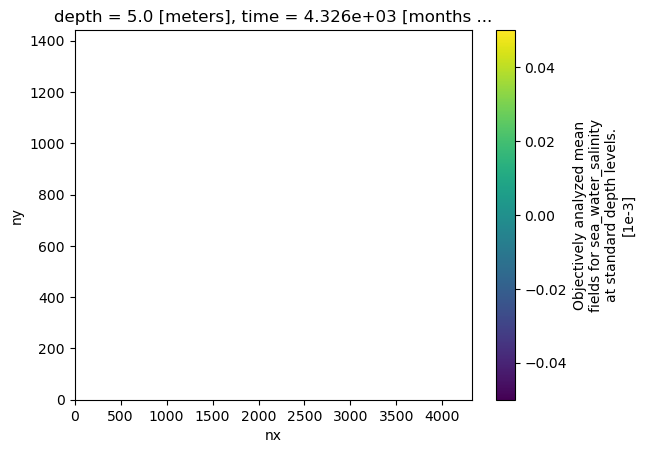

In [98]:
ds_woa_salt_regridded.where(hydrography_mask_da==shelf_id).sel(depth=5.0).plot()

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 29.72 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


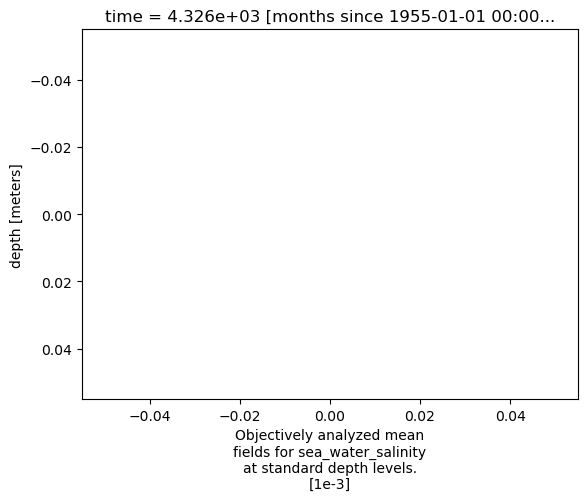

In [99]:
# THIS IS NOT ACCURATE - NEED TO DO A GRID AWARE AVERAGE
# PRELIMINARY RESULT

ds_woa_salt_regridded.where(hydrography_mask_da==shelf_id).mean(
            dim=['nx', 'ny']).plot(y='depth', yincrease=False)

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 29.72 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


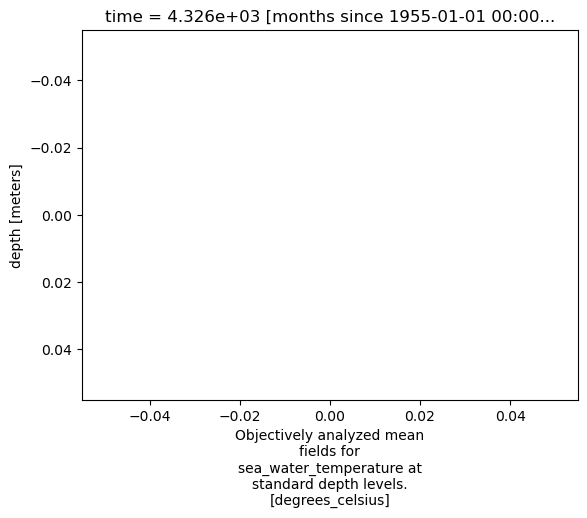

In [100]:
# THIS IS NOT ACCURATE - NEED TO DO A GRID AWARE AVERAGE
# PRELIMINARY RESULT

ds_woa_temp_regridded.where(hydrography_mask_da==shelf_id).mean(
                    dim=['nx', 'ny']).plot(y='depth', yincrease=False)